## Grid Search for Bipartite Hyperparameters

This notebook performs a grid search to find the best hyperparameters for the bipartite word-alignment model. We evaluate the (α, λ, lexical-normalization) combinations on each manually annotated ground-truth set independently - one section per (region × ASR-model) combination - and select the combination that yields the highest mean alignment accuracy.

In [1]:
import sys
import json
import numpy as np
from pathlib import Path

# locate project root by walking up until requirements.txt is found
_anchor = Path.cwd().resolve()
PROJECT_ROOT = next(p for p in (_anchor, *_anchor.parents) if (p / "requirements.txt").exists())
sys.path.insert(0, str(PROJECT_ROOT / "scripts" / "domain"))
sys.path.insert(0, str(PROJECT_ROOT / "scripts" / "utils"))

# hyperparameters to search over
alphas = np.linspace(0, 1, 21)  # lexical vs. positional weight (1 = lexical only)
lambdas = np.linspace(0, 1, 21)  # epsilon penalty (0 = no penalty, 1 = max penalty)
lexical_normalization_modes = [False, True]  # use_global_lexical_normalization
positional_modes = [False, True]  # use_squared_positional: linear vs. squared positional

n_combos = len(alphas) * len(lambdas) * len(lexical_normalization_modes) * len(positional_modes)
print(f"Alpha:  {len(alphas)} values, range [{alphas[0]:.2f}, {alphas[-1]:.2f}]")
print(f"Lambda: {len(lambdas)} values, range [{lambdas[0]:.2f}, {lambdas[-1]:.2f}]")
print(f"Total combinations: {n_combos:,}")

Alpha:  21 values, range [0.00, 1.00]
Lambda: 21 values, range [0.00, 1.00]
Total combinations: 1,764


In [2]:
from bipartite_hyperparameters_grid_search import (
    grid_search, pivot_accuracy_grids, print_best_accuracy_summary,
)
from plot_helpers import plot_grid_search_heatmaps

GT_DIR = PROJECT_ROOT / "experiments" / "hyperparameter_tuning"


def load_ground_truth(path):
    with open(path, encoding="utf-8-sig") as f:
        entries = json.load(f)
    for entry in entries:
        entry["alignment"] = {int(k): v for k, v in entry["alignment"].items()}
    return entries


def run_grid_search(gt_filename, label):
    entries = load_ground_truth(GT_DIR / gt_filename)
    print(f"{label}: {len(entries)} entries")
    df = grid_search(entries, alphas, lambdas, lexical_normalization_modes, positional_modes)
    accuracy_grids = pivot_accuracy_grids(df)

    # one figure per lexical-normalization mode, each comparing linear vs. squared positional
    for lex_norm in lexical_normalization_modes:
        panels = [
            (accuracy_grids[(lex_norm, pos_sq)], f"squared_positional={pos_sq}")
            for pos_sq in positional_modes
        ]
        plot_grid_search_heatmaps(
            panels=panels,
            alphas=alphas,
            lambdas=lambdas,
            subtitle=f"{label}: global_lexical_norm={lex_norm}",
        )

    for lex_norm in lexical_normalization_modes:
        for pos_sq in positional_modes:
            subset = df[
                (df["use_global_lexical_normalization"] == lex_norm)
                & (df["use_squared_positional"] == pos_sq)
            ]
            print_best_accuracy_summary(
                subset,
                f"global_lex_norm={lex_norm}, squared_pos={pos_sq}: ",
            )
    return df

## Wallis DIT

Wallis DIT: 100 entries


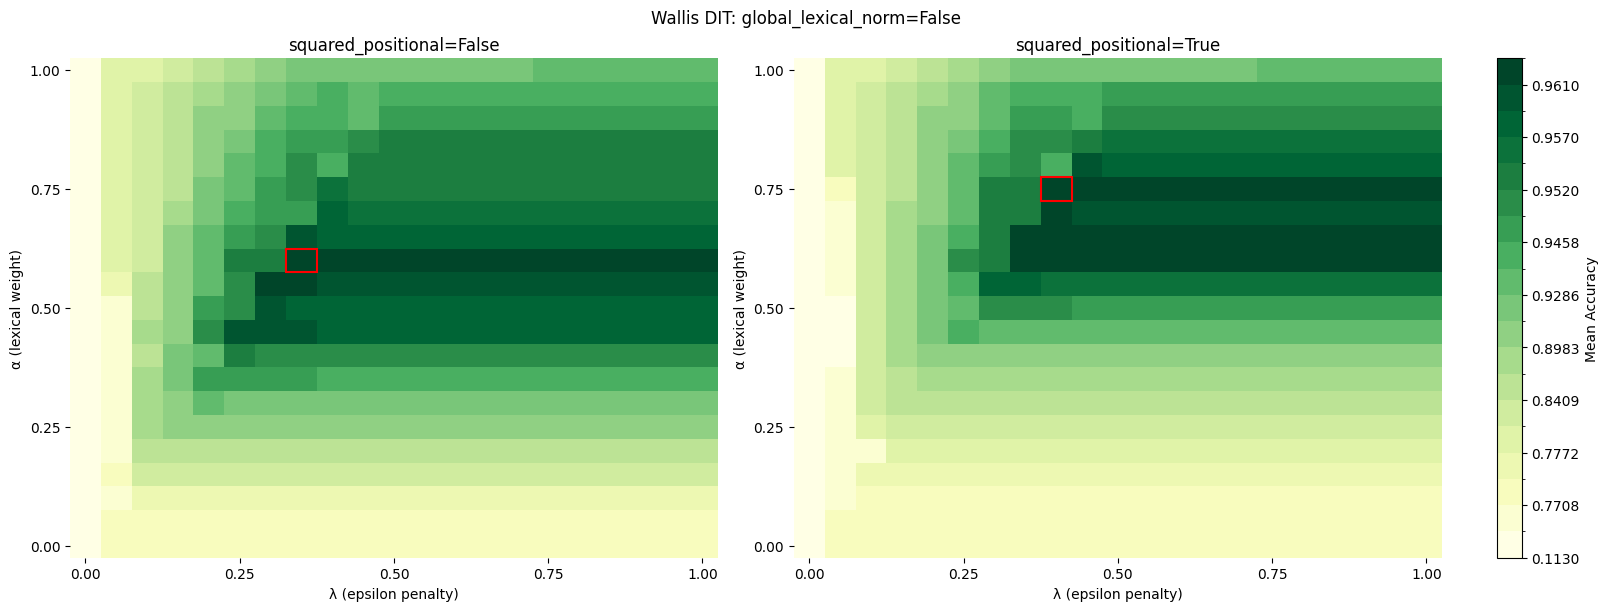

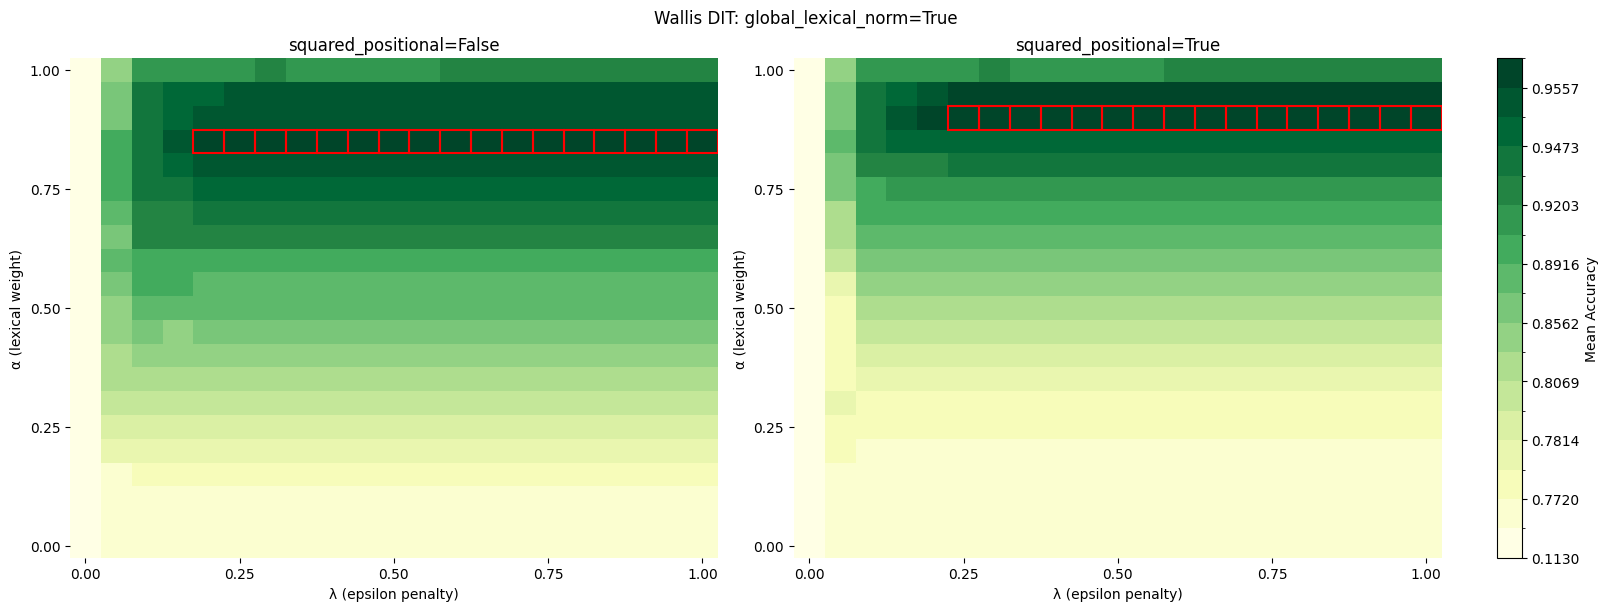

global_lex_norm=False, squared_pos=False: Best accuracy = 0.96215 (1 tied)
  α tied: ['0.60']
  λ tied: ['0.35']
global_lex_norm=False, squared_pos=True: Best accuracy = 0.96477 (1 tied)
  α tied: ['0.75']
  λ tied: ['0.40']
global_lex_norm=True, squared_pos=False: Best accuracy = 0.95574 (17 tied)
  α tied: ['0.85']
  λ tied: ['0.20', '0.25', '0.30', '0.35', '0.40', '0.45', '0.50', '0.55', '0.60', '0.65', '0.70', '0.75', '0.80', '0.85', '0.90', '0.95', '1.00']
global_lex_norm=True, squared_pos=True: Best accuracy = 0.95756 (16 tied)
  α tied: ['0.90']
  λ tied: ['0.25', '0.30', '0.35', '0.40', '0.45', '0.50', '0.55', '0.60', '0.65', '0.70', '0.75', '0.80', '0.85', '0.90', '0.95', '1.00']


In [3]:
df_wallis_dit = run_grid_search("samples_ground_truth_alignments_wallis_dit.json", "Wallis DIT")

## Wallis DAT

Wallis DAT: 100 entries


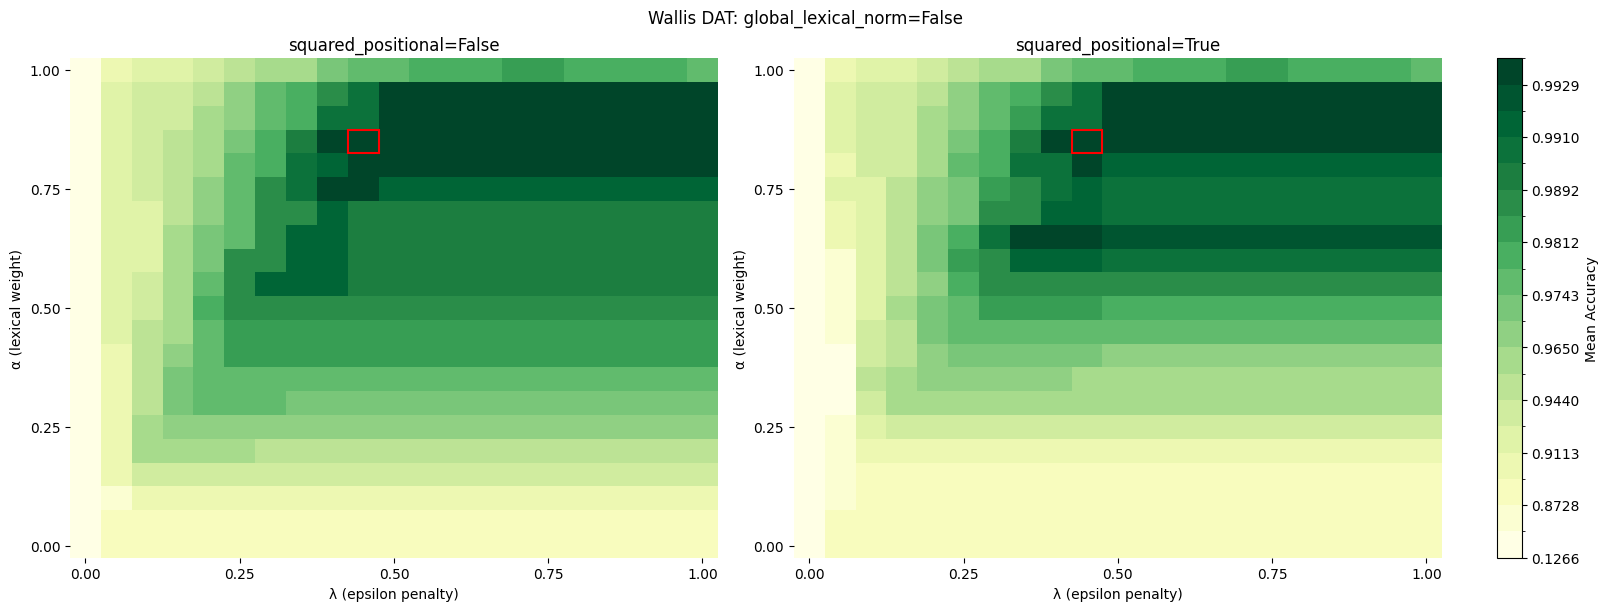

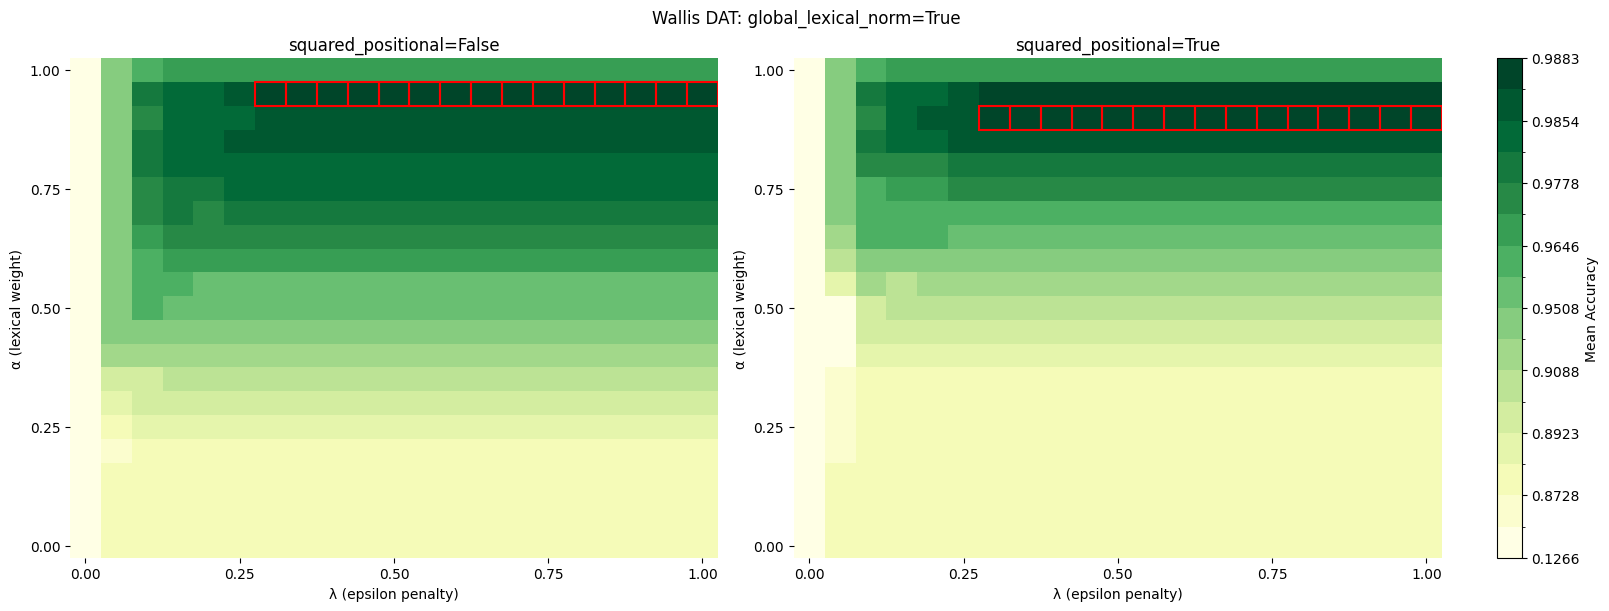

global_lex_norm=False, squared_pos=False: Best accuracy = 0.99667 (1 tied)
  α tied: ['0.85']
  λ tied: ['0.45']
global_lex_norm=False, squared_pos=True: Best accuracy = 0.99667 (1 tied)
  α tied: ['0.85']
  λ tied: ['0.45']
global_lex_norm=True, squared_pos=False: Best accuracy = 0.98787 (15 tied)
  α tied: ['0.95']
  λ tied: ['0.30', '0.35', '0.40', '0.45', '0.50', '0.55', '0.60', '0.65', '0.70', '0.75', '0.80', '0.85', '0.90', '0.95', '1.00']
global_lex_norm=True, squared_pos=True: Best accuracy = 0.98831 (15 tied)
  α tied: ['0.90']
  λ tied: ['0.30', '0.35', '0.40', '0.45', '0.50', '0.55', '0.60', '0.65', '0.70', '0.75', '0.80', '0.85', '0.90', '0.95', '1.00']


In [4]:
df_wallis_dat = run_grid_search("samples_ground_truth_alignments_wallis_dat.json", "Wallis DAT")

## Zürich DIT

Zürich DIT: 100 entries


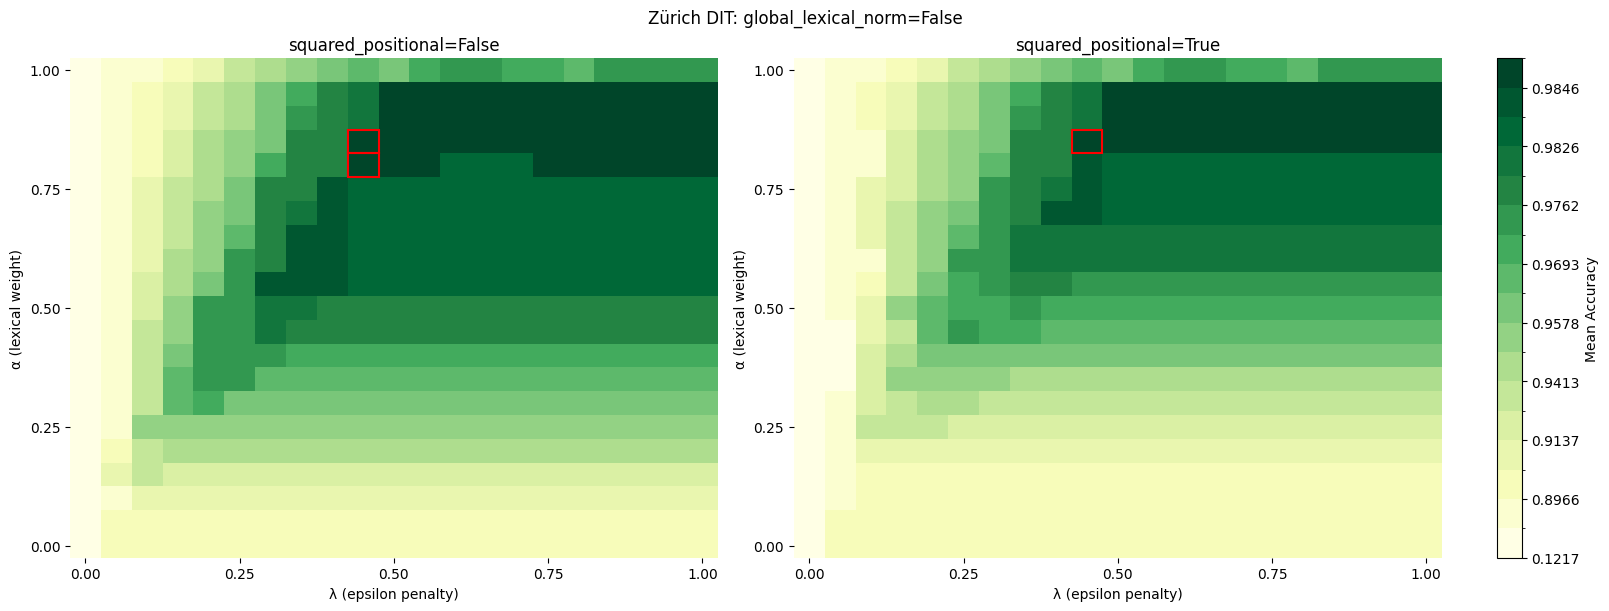

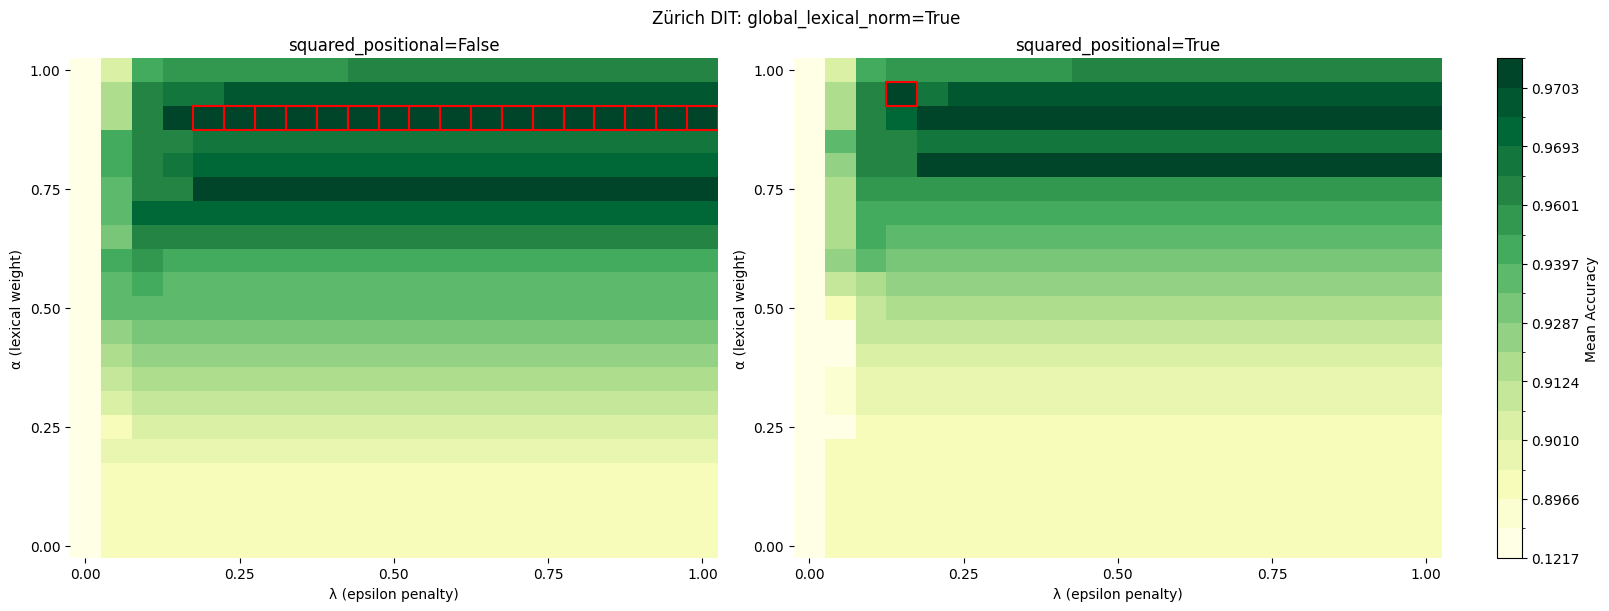

global_lex_norm=False, squared_pos=False: Best accuracy = 0.98561 (2 tied)
  α tied: ['0.80', '0.85']
  λ tied: ['0.45']
global_lex_norm=False, squared_pos=True: Best accuracy = 0.98561 (1 tied)
  α tied: ['0.85']
  λ tied: ['0.45']
global_lex_norm=True, squared_pos=False: Best accuracy = 0.97294 (17 tied)
  α tied: ['0.90']
  λ tied: ['0.20', '0.25', '0.30', '0.35', '0.40', '0.45', '0.50', '0.55', '0.60', '0.65', '0.70', '0.75', '0.80', '0.85', '0.90', '0.95', '1.00']
global_lex_norm=True, squared_pos=True: Best accuracy = 0.97072 (1 tied)
  α tied: ['0.95']
  λ tied: ['0.15']


In [5]:
df_zurich_dit = run_grid_search("samples_ground_truth_alignments_zurich_dit.json", "Zürich DIT")

## Zürich DAT

Zürich DAT: 100 entries


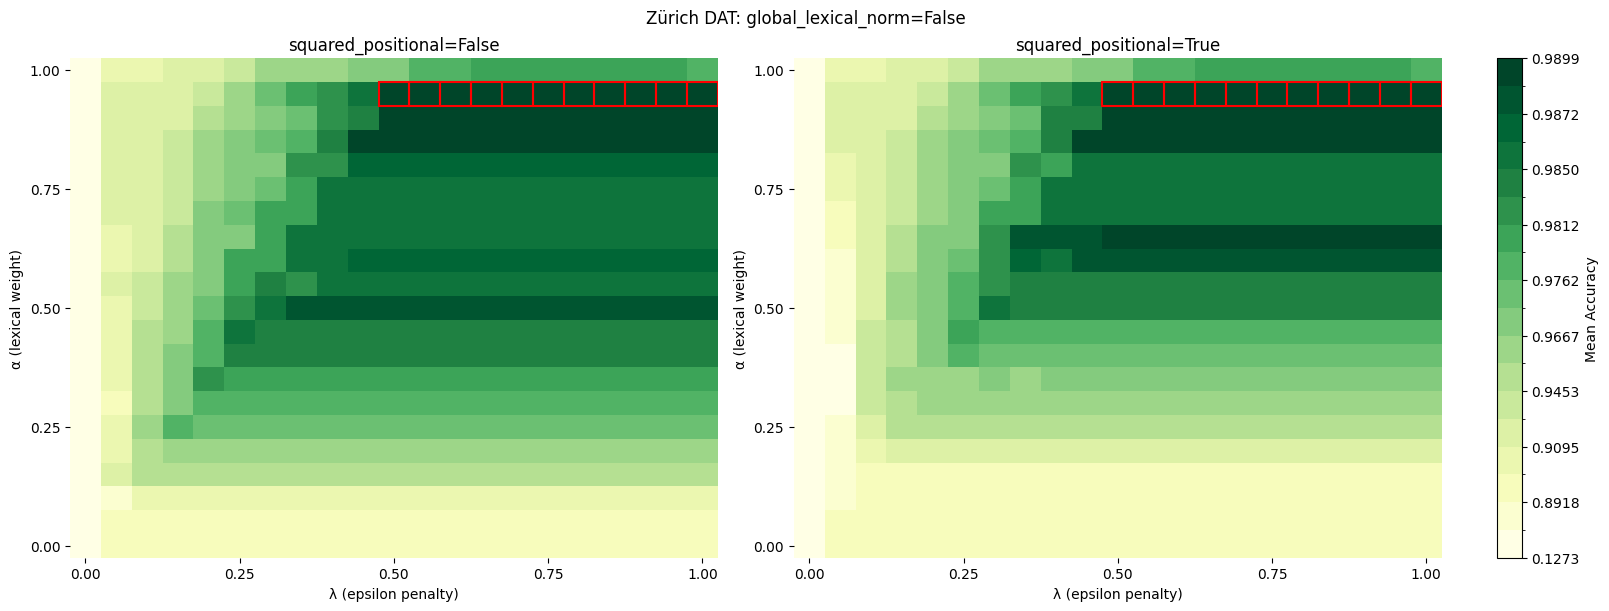

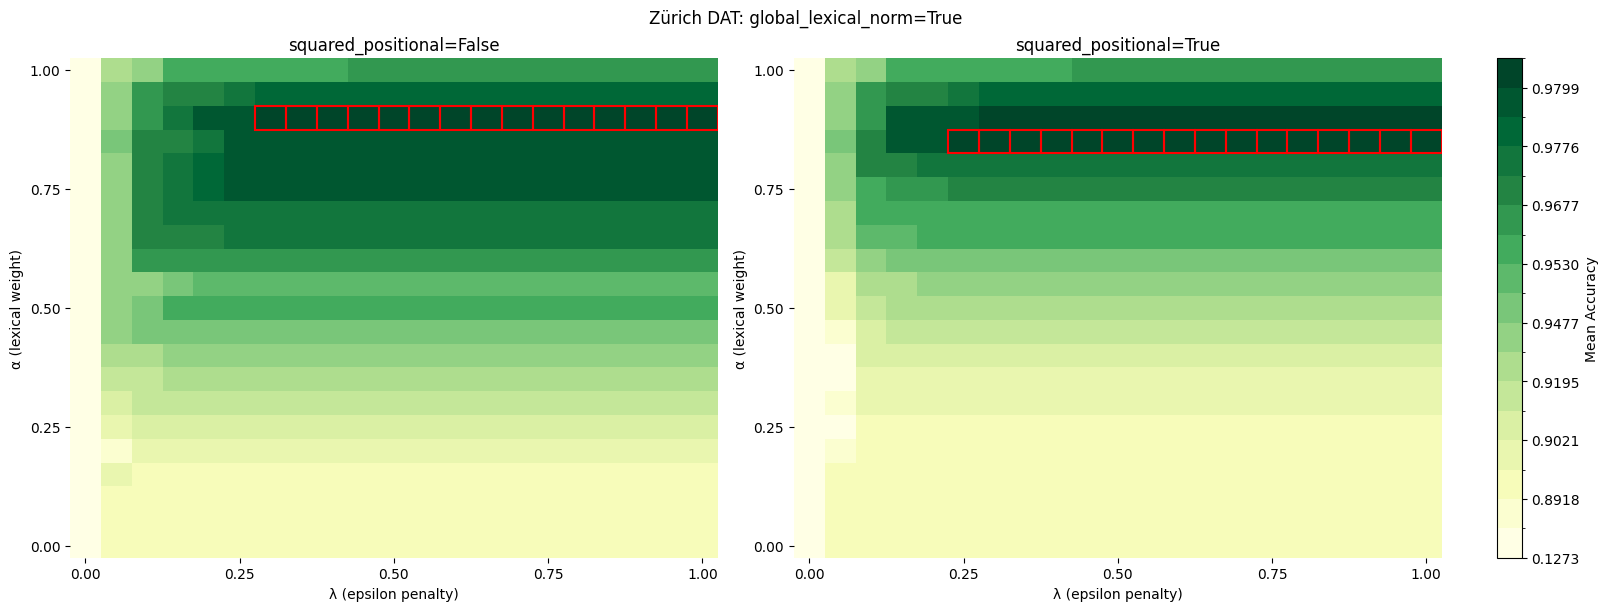

global_lex_norm=False, squared_pos=False: Best accuracy = 0.98992 (11 tied)
  α tied: ['0.95']
  λ tied: ['0.50', '0.55', '0.60', '0.65', '0.70', '0.75', '0.80', '0.85', '0.90', '0.95', '1.00']
global_lex_norm=False, squared_pos=True: Best accuracy = 0.98992 (11 tied)
  α tied: ['0.95']
  λ tied: ['0.50', '0.55', '0.60', '0.65', '0.70', '0.75', '0.80', '0.85', '0.90', '0.95', '1.00']
global_lex_norm=True, squared_pos=False: Best accuracy = 0.97992 (15 tied)
  α tied: ['0.90']
  λ tied: ['0.30', '0.35', '0.40', '0.45', '0.50', '0.55', '0.60', '0.65', '0.70', '0.75', '0.80', '0.85', '0.90', '0.95', '1.00']
global_lex_norm=True, squared_pos=True: Best accuracy = 0.98100 (16 tied)
  α tied: ['0.85']
  λ tied: ['0.25', '0.30', '0.35', '0.40', '0.45', '0.50', '0.55', '0.60', '0.65', '0.70', '0.75', '0.80', '0.85', '0.90', '0.95', '1.00']


In [6]:
df_zurich_dat = run_grid_search("samples_ground_truth_alignments_zurich_dat.json", "Zürich DAT")

## Final hyperparameter selection

Fixed parameters based on results from the grid search:
- **`use_global_lexical_normalization = False`**: Performed best in all four sections.
- **`use_squared_positional = True`**: ties or marginally beats the linear positional mode on every section.
- **(α, λ)**: the mean of the four per-section optimal (α, λ) at the fixed binary modes. The resulting mean is then rounded to the nearest value of α and λ that we actually evaluated.

In [ ]:
import pandas as pd

use_global_lexical_normalization = False
use_squared_positional = True

sections = {
    name: df[
        (df["use_global_lexical_normalization"] == use_global_lexical_normalization)
        & (df["use_squared_positional"] == use_squared_positional)
    ]
    for name, df in {
        "Wallis DIT": df_wallis_dit,
        "Wallis DAT": df_wallis_dat,
        "Zürich DIT": df_zurich_dit,
        "Zürich DAT": df_zurich_dat,
    }.items()
}


def accuracy_for_point(subset, alpha, lambda_):
    matches = subset[
        np.isclose(subset["alpha"], alpha) & np.isclose(subset["lambda"], lambda_)
    ]
    return float(matches["accuracy"].iloc[0])


# Each section's own best (α, λ) at the fixed modes.
# Tie-break: lowest λ first, then lowest α (per thesis convention).
optima_rows = []
for name, subset in sections.items():
    best_acc = subset["accuracy"].max()
    tied = subset[subset["accuracy"] == best_acc]
    best_row = tied.sort_values(["lambda", "alpha"]).iloc[0]
    optima_rows.append({
        "section": name,
        "alpha": best_row["alpha"],
        "lambda": best_row["lambda"],
        "best": best_row["accuracy"],
    })
per_section_optima = pd.DataFrame(optima_rows).set_index("section")

# round mean of the per-section optimal (α, λ) to nearest evaluated value.
selected_alpha = float(alphas[np.argmin(np.abs(alphas - per_section_optima["alpha"].mean()))])
selected_lambda = float(lambdas[np.argmin(np.abs(lambdas - per_section_optima["lambda"].mean()))])

# compare selected to section own optimum
breakdown = per_section_optima[["best"]].copy()
breakdown["accuracy"] = [
    accuracy_for_point(subset, selected_alpha, selected_lambda) for subset in sections.values()
]
breakdown["delta"] = breakdown["best"] - breakdown["accuracy"]
breakdown = breakdown[["accuracy", "best", "delta"]]


print("Per-section optima at the fixed modes:")
print(f"  {'section':<10}  {'alpha':>5}  {'lambda':>6}  {'best':>7}")
for name, row in per_section_optima.iterrows():
    print(f"  {name:<10}  {row['alpha']:>5.2f}  {row['lambda']:>6.2f}  {row['best']:>7.5f}")
print()
print("Selected hyperparameters:")
print(f"  α                                = {selected_alpha:.2f}")
print(f"  λ                                = {selected_lambda:.2f}")
print(f"  use_global_lexical_normalization = {use_global_lexical_normalization}")
print(f"  use_squared_positional           = {use_squared_positional}")
print()
print("Per-section accuracy at the selected point (delta = best − accuracy):")
print(f"  {'section':<10}  {'accuracy':>8}  {'best':>7}  {'delta':>7}")
for name, row in breakdown.iterrows():
    print(f"  {name:<10}  {row['accuracy']:>8.5f}  {row['best']:>7.5f}  {row['delta']:>7.5f}")
print()
print(f"  Mean delta: {breakdown['delta'].mean():.5f}    Max delta: {breakdown['delta'].max():.5f}")